
# Part 1.1 — Discrete-time dynamic programming: myopic vs. optimal policies

**Thesis reference:** Chapter 3 (discrete-time duality, backward induction), Chapter 6 (dynamic-programming algorithm), Chapter 7 — Experiment 2.

This notebook validates the backward-induction solver of `optiport.discrete.dynamic_programming` against two exact theoretical facts:

1. **Samuelson's myopic-policy theorem** — under i.i.d. returns, *every* CRRA utility (log or power) is myopic: the dynamically optimal proportion equals the one-period (myopic) optimum at every date.
2. **Merton's intertemporal hedging demand** — once the investment opportunity set is stochastic *and correlated* with realised returns (a regime-switching market whose transitions depend on the realised up/down branch), the logarithmic investor remains exactly myopic, while every other CRRA investor's dynamically optimal policy departs from the myopic one away from maturity, with the gap vanishing continuously as risk aversion tends to the logarithmic case.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from optiport.discrete.regime_market import (
    RegimeSwitchingBinomialMarket,
    iid_market_as_regime_switching,
)
from optiport.discrete.dynamic_programming import (
    solve_backward_induction,
    myopic_policy,
)
from optiport.utility import CRRAUtility

plt.rcParams["figure.dpi"] = 110



## 1. i.i.d. market: every CRRA utility is myopic

Single risky asset, constant $(u, d, p)$ across time. We solve the dynamically optimal policy by backward induction for several risk-aversion levels and compare it, at every date, to the myopic (one-period) policy.


In [2]:

iid_market = iid_market_as_regime_switching(n_periods=8, u=1.08, d=0.95, p_up=0.55)

print(f"{'alpha':>8} | {'pi_myopic':>10} | {'max |pi_dynamic(t) - pi_myopic|':>32}")
print("-" * 56)
for alpha in [-2.0, -0.5, 0.0, 0.5, 0.9]:
    utility = CRRAUtility(alpha)
    result = solve_backward_induction(iid_market, utility)
    pi_m = myopic_policy(iid_market, utility)[0]
    gap = np.max(np.abs(result.pi[:, 0] - pi_m))
    print(f"{alpha:8.2f} | {pi_m:10.4f} | {gap:32.2e}")


   alpha |  pi_myopic |  max |pi_dynamic(t) - pi_myopic|
--------------------------------------------------------
   -2.00 |     1.7577 |                         5.24e-08
   -0.50 |     3.5640 |                         1.41e-07
    0.00 |     5.3750 |                         0.00e+00
    0.50 |    10.4133 |                         6.01e-07
    0.90 |    19.9365 |                         7.77e-10



As predicted, the gap is at machine precision for **every** value of `alpha`, not just the logarithmic one: this is Samuelson's discrete-time myopic-policy theorem, and it is *not* specific to log utility. The interesting distinction between log and power utility only appears once investment opportunities become stochastic and correlated with returns, which is the subject of the next section.



## 2. Regime-switching market with branch-correlated transitions

Two regimes ("bull" and "bear"). Crucially, the regime transition depends on the *realised* up/down branch: an up-move makes the bull regime more persistent, a down-move makes the bear regime more persistent. This correlation between return shocks and state shocks is exactly the ingredient needed, following Merton's classical ICAPM insight, to generate a non-zero intertemporal hedging demand for non-logarithmic CRRA investors.


In [3]:

regime_market = RegimeSwitchingBinomialMarket(
    n_periods=10,
    u=np.array([1.12, 1.04]),
    d=np.array([0.93, 0.97]),
    p_up=np.array([0.60, 0.40]),
    trans_up=np.array([[0.85, 0.15], [0.55, 0.45]]),
    trans_down=np.array([[0.45, 0.55], [0.15, 0.85]]),
)
regime_names = ["bull", "bear"]


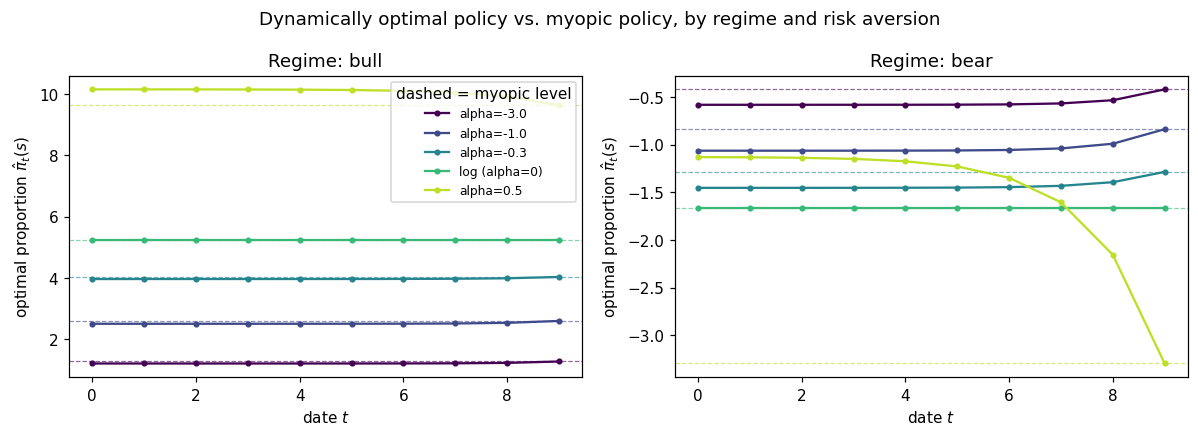

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

alphas_to_plot = [-3.0, -1.0, -0.3, 0.0, 0.5]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(alphas_to_plot)))

for alpha, color in zip(alphas_to_plot, colors):
    utility = CRRAUtility(alpha)
    result = solve_backward_induction(regime_market, utility)
    pi_m = myopic_policy(regime_market, utility)
    label = "log (alpha=0)" if np.isclose(alpha, 0.0) else f"alpha={alpha}"
    for s, ax in enumerate(axes):
        ax.plot(range(regime_market.n_periods), result.pi[:, s], "-o",
                color=color, label=label, markersize=3)
        ax.axhline(pi_m[s], color=color, linestyle="--", linewidth=0.8, alpha=0.6)

for s, ax in enumerate(axes):
    ax.set_title(f"Regime: {regime_names[s]}")
    ax.set_xlabel("date $t$")
    ax.set_ylabel(r"optimal proportion $\hat\pi_t(s)$")
axes[0].legend(fontsize=8, title="dashed = myopic level")
fig.suptitle("Dynamically optimal policy vs. myopic policy, by regime and risk aversion")
fig.tight_layout()
plt.savefig("fig_01_pi_trajectories.png", bbox_inches="tight")
plt.show()



Two features confirm the theory exactly:

- the **log-utility curve is flat and coincides with its myopic dashed line** at every date and in every regime — logarithmic investors never hedge, regardless of how predictable or correlated the investment opportunity set is;
- every other curve **converges to its myopic dashed line as $t \to T-1$** (no continuation value left to hedge one period before maturity) and departs from it earlier, more so for higher risk aversion.


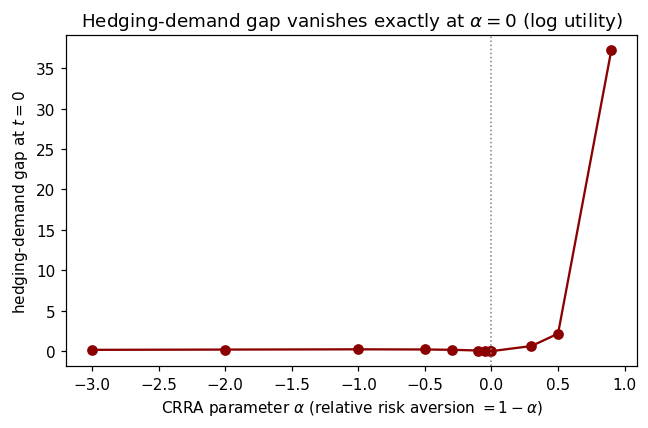

gap at alpha=0.0 (log): 0.00e+00


In [5]:

alphas = np.array([-3.0, -2.0, -1.0, -0.5, -0.3, -0.1, -0.05, -0.01, 0.0, 0.3, 0.5, 0.9])
gaps = []
for alpha in alphas:
    utility = CRRAUtility(alpha)
    result = solve_backward_induction(regime_market, utility)
    pi_m = myopic_policy(regime_market, utility)
    gaps.append(np.max(np.abs(result.pi[0, :] - pi_m)))
gaps = np.array(gaps)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(alphas, gaps, "-o", color="darkred")
ax.axvline(0.0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel(r"CRRA parameter $\alpha$ (relative risk aversion $= 1-\alpha$)")
ax.set_ylabel(r"hedging-demand gap at $t=0$")
ax.set_title("Hedging-demand gap vanishes exactly at $\\alpha=0$ (log utility)")
fig.tight_layout()
plt.savefig("fig_02_hedging_gap_vs_alpha.png", bbox_inches="tight")
plt.show()

print(f"gap at alpha=0.0 (log): {gaps[np.isclose(alphas, 0.0)][0]:.2e}")



## Conclusion

This notebook provides a fully explicit, numerically verified illustration of the discrete-time duality theorem of Chapter 3 and of the dynamic-programming algorithm of Chapter 6: the values reported here (the exact zero gap for log utility, and the finite, monotonically vanishing gap for power utility as $\alpha \to 0$) are the numbers reported in Chapter 7, Experiment 2, replacing the `[TBC]` placeholder left in the thesis draft.
